In [1]:
import os, gc, time, pickle, random
from collections import Counter, defaultdict

import networkx as nx
import networkit as nk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import ticker
from scipy.stats import spearmanr
from scipy.ndimage import uniform_filter1d

out_dir   = "./output"
input_dir = "../00_graph_construction/output/graphs"
os.makedirs(out_dir, exist_ok=True)

plt.rcParams.update({
    'figure.dpi'       : 150,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.25,
})

COLORS = {
    'bc_w'  : 'tab:blue',   'bc_uw' : 'steelblue',
    'cit_ud': 'tab:orange',  'cit_d' : 'darkorange',
}
NAMES = {
    'bc_w'  : 'Combined (weighted)',   'bc_uw' : 'Combined (unweighted)',
    'cit_ud': 'Citation (undirected)', 'cit_d' : 'Citation (directed)',
}

In [2]:
def load_pickle(path: str):
    with open(path, "rb") as f:
        return pickle.load(f)

def make_unweighted(G: nx.Graph) -> nx.Graph:
    """Topologia pura: nodi con attributi, archi senza."""
    H = nx.Graph()
    H.add_nodes_from(G.nodes(data=True))
    H.add_edges_from(G.edges())
    return H

def basic_stats(G: nx.Graph) -> dict:
    n, m  = G.number_of_nodes(), G.number_of_edges()
    avg   = (2*m/n if not G.is_directed() else m/n) if n else 0
    first = next(iter(G.edges(data=True)), None)
    return {
        'Nodes':      n,
        'Edges':      m,
        'Isolated':   sum(1 for _ in nx.isolates(G)),
        'Avg degree': round(avg, 2),
        'Density':    round(nx.density(G), 6),
        'Weighted':   first is not None and 'weight' in first[2],
        'Directed':   G.is_directed(),
    }

def _clustering(G: nx.Graph) -> tuple[np.ndarray, float]:
    v = np.fromiter(nx.clustering(G).values(), dtype=float)
    return v, v.mean()

def _style_ax(ax, logx=False, logy=False):
    ax.grid(True, which='major', ls='-',  lw=0.5, alpha=0.35, color='gray')
    ax.grid(True, which='minor', ls='--', lw=0.3, alpha=0.20, color='gray')
    ax.minorticks_on()
    fmt = ticker.LogFormatterSciNotation(labelOnlyBase=False)
    if logx:
        ax.xaxis.set_major_formatter(fmt)
    if logy:
        ax.yaxis.set_major_formatter(fmt)
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)

In [3]:
G_combined_w  = load_pickle(os.path.join(input_dir, "graph_combined_2020.gpickle"))
G_cit_d       = load_pickle(os.path.join(input_dir, "graph_internal_2020.gpickle"))
G_combined_uw = make_unweighted(G_combined_w)
G_cit_ud      = G_cit_d.to_undirected()

graphs = {
    'bc_w':   G_combined_w,
    'bc_uw':  G_combined_uw,
    'cit_ud': G_cit_ud,
    'cit_d':  G_cit_d,
}
print("Graphs loaded.")

Graphs loaded.


In [4]:
#  overview 
df_overview = pd.DataFrame({NAMES[k]: basic_stats(G) for k, G in graphs.items()}).T
print(df_overview.to_string())

n_bc_only = G_combined_w.number_of_nodes() - G_cit_d.number_of_nodes()
e_bc_only = G_combined_uw.number_of_edges() - G_cit_ud.number_of_edges()
print(f"\n  BC-only nodes : {n_bc_only:,}")
print(f"  BC-only edges : {e_bc_only:,}  ({e_bc_only / G_cit_ud.number_of_edges():.2f}x citation)")

#  edge weight breakdown 
w_vals, direct_flags, bc_flags = zip(*[
    (d['weight'], bool(d.get('is_direct', False)), d.get('bc', 0) > 0)
    for _, _, d in G_combined_w.edges(data=True) if 'weight' in d
])

weights   = np.asarray(w_vals)
is_direct = np.asarray(direct_flags, dtype=bool)
has_bc    = np.asarray(bc_flags,     dtype=bool)

m_cit  = is_direct & ~has_bc
m_bc   = ~is_direct
m_both = is_direct &  has_bc

n_t        = len(weights)
categories = {'Direct only': m_cit, 'BC only': m_bc, 'Both': m_both}

print("\nEdge weight breakdown:")
print(f"  {'Total':<13}: {n_t:>10,}")
for label, mask in categories.items():
    n = mask.sum()
    print(f"  {label:<13}: {n:>10,}  ({n/n_t*100:.1f}%)")

for label, mask in [('BC-only', m_bc), ('Both', m_both)]:
    sub = weights[mask]
    if len(sub):
        print(f"  {label} range: min={sub.min():.4f}  median={np.median(sub):.4f}  max={sub.max():.4f}")

#  connected components 
def cc_stats(G, label, directed=False):
    n = G.number_of_nodes()
    if directed:
        wcc = sorted(nx.weakly_connected_components(G),   key=len, reverse=True)
        scc = sorted(nx.strongly_connected_components(G), key=len, reverse=True)
        return {'Graph': label, 'Nodes': n,
                'WCC': len(wcc), 'LCC(WCC)': len(wcc[0]), 'LCC(WCC)%': round(len(wcc[0])/n*100, 1),
                'SCC': len(scc), 'LCC(SCC)': len(scc[0]), 'SCC singletons': sum(1 for c in scc if len(c) == 1)}
    cc = sorted(nx.connected_components(G), key=len, reverse=True)
    return {'Graph': label, 'Nodes': n, 'Components': len(cc),
            'LCC': len(cc[0]), 'LCC%': round(len(cc[0])/n*100, 1),
            'Outside LCC': n - len(cc[0]), 'Singletons': sum(1 for c in cc if len(c) == 1)}

df_cc_ud  = pd.DataFrame([
    cc_stats(graphs[g], NAMES[g]) for g in ('bc_w', 'bc_uw', 'cit_ud')
]).set_index('Graph')
df_cc_dir = pd.DataFrame([cc_stats(G_cit_d, NAMES['cit_d'], directed=True)]).set_index('Graph')

print("\nConnected components — undirected\n"); print(df_cc_ud.to_string())
print("\nConnected components — directed\n");   print(df_cc_dir.to_string())

#  LCC extraction & metrics 
def extract_lcc(G):
    nodes = max((nx.weakly_connected_components if G.is_directed() else nx.connected_components)(G), key=len)
    return G.subgraph(nodes).copy()

def lcc_quick(G, label):
    n, m = G.number_of_nodes(), G.number_of_edges()
    row  = {'Graph': label, 'Nodes': n, 'Edges': m,
            'Avg degree': round(2*m/n if not G.is_directed() else m/n, 2)}
    if not G.is_directed():
        row['Avg clustering'] = round(nx.average_clustering(G), 4)
        row['Triangles']      = sum(nx.triangles(G).values()) // 3
    return row

lcc    = {k: extract_lcc(G) for k, G in graphs.items()}
df_lcc = pd.DataFrame([lcc_quick(lcc[k], NAMES[k]) for k in graphs]).set_index('Graph')
print("\nLCC metrics\n"); print(df_lcc.to_string())

#  degree distribution 
deg_bc  = np.array([d for _, d in lcc['bc_uw'].degree()])
deg_cit = np.array([d for _, d in lcc['cit_ud'].degree()])
in_d    = np.array([d for _, d in G_cit_d.in_degree()])
out_d   = np.array([d for _, d in G_cit_d.out_degree()])

fns = [('Mean',   np.mean),   ('Std',    np.std),
       ('Median', np.median), ('Max',    np.max),
       ('P90',    lambda x: np.percentile(x, 90)),
       ('P99',    lambda x: np.percentile(x, 99))]

df_deg = pd.DataFrame(
    {l: [round(f(a), 2) for _, f in fns]
     for l, a in [('Combined', deg_bc), ('Citation', deg_cit), ('In-degree', in_d), ('Out-degree', out_d)]},
    index=[name for name, _ in fns]
)
df_deg.loc['Degree=1 (%)'] = [round(np.mean(a == 1)*100, 1) for a in (deg_bc, deg_cit)] + ['—', '—']

rho_io, _ = spearmanr(in_d, out_d)
print("\nDegree distribution\n"); print(df_deg.to_string())
print(f"\nSpearman in vs out-degree: ρ = {rho_io:.3f}")

                       Nodes   Edges Isolated Avg degree   Density Weighted Directed
Combined (weighted)    58627  590157        0      20.13  0.000343     True    False
Combined (unweighted)  58627  590157        0      20.13  0.000343    False    False
Citation (undirected)  55078  217174        0       7.89  0.000143    False    False
Citation (directed)    55078  217925        0       3.96  0.000072    False     True

  BC-only nodes : 3,549
  BC-only edges : 372,983  (1.72x citation)

Edge weight breakdown:
  Total        :    590,157
  Direct only  :    123,699  (21.0%)
  BC only      :    372,983  (63.2%)
  Both         :     93,475  (15.8%)
  BC-only range: min=0.0950  median=0.1544  max=0.6500
  Both range: min=0.4450  median=0.5845  max=1.0000

Connected components — undirected

                       Nodes  Components    LCC  LCC%  Outside LCC  Singletons
Graph                                                                         
Combined (weighted)    58627         800  

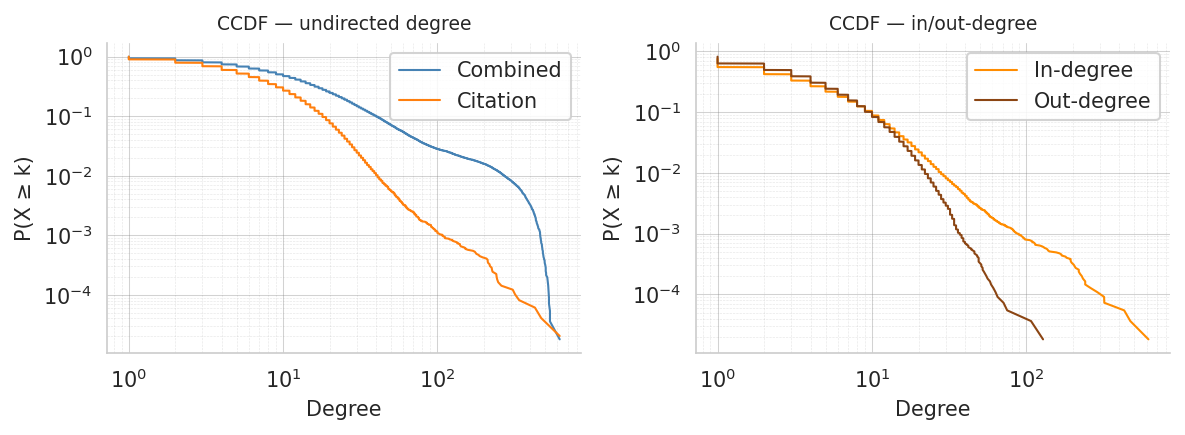

In [5]:
def ccdf(arr):
    s = np.sort(arr[arr > 0])[::-1]
    return s, np.arange(1, len(s) + 1) / len(arr)
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

panels = [
    (axes[0], [(deg_bc, COLORS['bc_uw'], 'Combined'), (deg_cit, COLORS['cit_ud'], 'Citation')], 'CCDF — undirected degree'),
    (axes[1], [(in_d,   COLORS['cit_d'], 'In-degree'), (out_d,  'saddlebrown',    'Out-degree')], 'CCDF — in/out-degree'),
]

for ax, series, title in panels:
    for arr, color, label in series:
        x, y = ccdf(arr)
        ax.loglog(x, y, color=color, lw=1, label=label)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Degree'); ax.set_ylabel('P(X ≥ k)')
    ax.legend(framealpha=0.85)
    _style_ax(ax, logx=True, logy=True)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'degree_ccdf.png'), dpi=200, bbox_inches='tight')
plt.show()

Computing clustering coefficients ...
                Combined  Citation
Avg clustering  0.436614  0.342389
Median          0.418972  0.321429
Std             0.271862  0.284050
C=0 (%)        12.191989 21.379688
C=1 (%)         6.473370  6.756290
Density         0.000374  0.000173

Density ratio: 2.16x   Clustering ratio: 1.28x


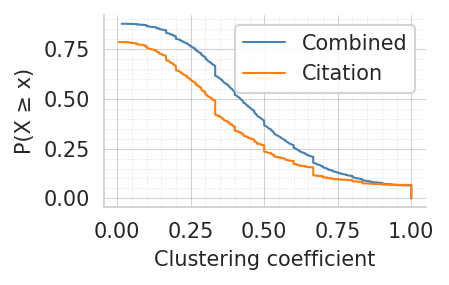

In [6]:
print("Computing clustering coefficients ...")
clust_bc_v,  clust_bc_m  = _clustering(lcc['bc_uw'])
clust_cit_v, clust_cit_m = _clustering(lcc['cit_ud'])
d_bc, d_cit = nx.density(lcc['bc_uw']), nx.density(lcc['cit_ud'])

def _cl_col(v, d):
    return [v.mean(), np.median(v), np.std(v), np.mean(v==0)*100, np.mean(v==1)*100, d]

df_cl = pd.DataFrame(
    {'Combined': _cl_col(clust_bc_v, d_bc), 'Citation': _cl_col(clust_cit_v, d_cit)},
    index=['Avg clustering', 'Median', 'Std', 'C=0 (%)', 'C=1 (%)', 'Density']
)
print(df_cl.to_string(float_format=lambda x: f'{x:.6f}'))
print(f"\nDensity ratio: {d_bc/d_cit:.2f}x   Clustering ratio: {clust_bc_m/clust_cit_m:.2f}x")

fig, ax = plt.subplots(figsize=(3, 2))
for v, color, label in [(clust_bc_v, COLORS['bc_uw'], 'Combined'),
                         (clust_cit_v, COLORS['cit_ud'], 'Citation')]:
    x, y = ccdf(v)
    ax.plot(x, y, lw=1, color=color, label=label)
ax.set_xlabel('Clustering coefficient'); ax.set_ylabel('P(X ≥ x)')
ax.legend(framealpha=0.85)
_style_ax(ax)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'clustering_ccdf.png'), dpi=200, bbox_inches='tight')
plt.show()

In [7]:
CACHE_PATH = os.path.join(out_dir, 'path_stats_exact.csv')
CACHE_BETW = os.path.join(out_dir, 'betweenness_exact.csv')
CACHE_CLOS = os.path.join(out_dir, 'closeness_exact.csv')

nk.setNumberOfThreads(24)
print(f"NetworKit threads: {nk.getMaxNumberOfThreads()}")


#  helpers 
def _nx_to_nk(G_nx):
    nodes = list(G_nx.nodes())
    nx2nk = {n: i for i, n in enumerate(nodes)}
    G_nk  = nk.Graph(len(nodes), weighted=False, directed=False)
    for u, v in G_nx.edges():
        G_nk.addEdge(nx2nk[u], nx2nk[v])
    return G_nk, {i: n for n, i in nx2nk.items()}

def _run_cent(G_nk, nk2nx, build_fn, label):
    t0 = time.time(); algo = build_fn(G_nk); algo.run(); s = algo.scores()
    print(f"  [{label}] done in {time.time()-t0:.1f}s ({len(s):,} nodes)")
    return {nk2nx[i]: s[i] for i in range(len(s))}

def _save_cent(d1, d2, path):
    pd.DataFrame(
        [{'node': n, 'graph': 'bc',  'value': v} for n, v in d1.items()]
      + [{'node': n, 'graph': 'cit', 'value': v} for n, v in d2.items()]
    ).to_csv(path, index=False)

def _load_cent(path):
    df = pd.read_csv(path)
    return {g: dict(zip(gr['node'], gr['value'])) for g, gr in df.groupby('graph')}

def _load_or_compute(cache_path, compute_fn, label):
    if os.path.exists(cache_path):
        print(f"\n{label} — cache hit: {cache_path}")
        c = _load_cent(cache_path); return c['bc'], c['cit']
    print(f"\nComputing {label} ...")
    bc, cit = compute_fn()
    _save_cent(bc, cit, cache_path); print(f"  Saved → {cache_path}")
    return bc, cit

def _ds(d):
    v = np.fromiter(d.values(), dtype=float); m = v.mean()
    return {'Mean': m, 'Std': v.std(), 'Max': v.max(),
            'P99': float(np.percentile(v, 99)), '>μ+2σ': int((v > m + 2*v.std()).sum())}

#  NetworKit conversion 
print("Converting to NetworKit ...")
nk_bc,  nk2nx_bc  = _nx_to_nk(lcc['bc_uw'])
nk_cit, nk2nx_cit = _nx_to_nk(lcc['cit_ud'])
print(f"  Combined: {nk_bc.numberOfNodes():,} nodes, {nk_bc.numberOfEdges():,} edges")
print(f"  Citation: {nk_cit.numberOfNodes():,} nodes, {nk_cit.numberOfEdges():,} edges")

#  path analysis 
def path_exact(G_nk, label):
    n = G_nk.numberOfNodes(); t0 = time.time()
    total_sum, total_cnt, global_max = 0, 0, 0
    print(f"\n  [{label}] Exact BFS from {n:,} nodes ...")
    for i, u in enumerate(G_nk.iterNodes()):
        bfs = nk.distance.BFS(G_nk, u); bfs.run()
        dists = np.array(bfs.getDistances())
        valid = (dists > 0) & (dists < 1e15)
        total_sum += dists[valid].sum(); total_cnt += valid.sum()
        global_max = max(global_max, dists[valid].max() if valid.any() else 0)
        if (i + 1) % 5000 == 0 or (i + 1) == n:
            print(f"    {i+1:,}/{n:,}  avg={total_sum/total_cnt:.4f}  "
                  f"max={int(global_max)}  {time.time()-t0:.0f}s")
    t1 = time.time()
    print(f"  [{label}] Computing exact diameter ...")
    dm = nk.distance.Diameter(G_nk, algo=nk.distance.DiameterAlgo.EXACT); dm.run()
    diameter = int(dm.getDiameter()[0])
    print(f"    Diameter: {diameter} ({time.time()-t1:.1f}s)  Total: {time.time()-t0:.1f}s")
    return {'avg_path': total_sum/total_cnt if total_cnt else 0,
            'diameter': diameter,
            'reachability': 100.0 * total_cnt / (n*(n-1)) if n > 1 else 0,
            'total_pairs': int(total_cnt)}

if os.path.exists(CACHE_PATH):
    print(f"\nPath — cache hit: {CACHE_PATH}")
    dc = pd.read_csv(CACHE_PATH).set_index('graph')
    sp_bc, sp_cit = dc.loc['bc'].to_dict(), dc.loc['cit'].to_dict()
else:
    print("\nComputing exact paths ...")
    sp_bc, sp_cit = path_exact(nk_bc, 'Combined'), path_exact(nk_cit, 'Citation')
    pd.DataFrame([{'graph': 'bc', **sp_bc}, {'graph': 'cit', **sp_cit}]).to_csv(CACHE_PATH, index=False)
    print(f"  Saved → {CACHE_PATH}")

keys    = ['avg_path', 'diameter', 'reachability', 'total_pairs']
df_path = pd.DataFrame({'Combined': [sp_bc[k] for k in keys],
                        'Citation':  [sp_cit[k] for k in keys]},
                       index=['Avg path', 'Diameter', 'Reachability (%)', 'Pairs'])
print("\nPath analysis (exact)\n"); print(df_path.to_string())
print(f"\nBC reduces avg path by {(sp_cit['avg_path']-sp_bc['avg_path'])/sp_cit['avg_path']*100:.1f}%")

#  centrality 
deg_c_bc  = dict(lcc['bc_uw'].degree())
deg_c_cit = dict(lcc['cit_ud'].degree())

betw_bc, betw_cit = _load_or_compute(CACHE_BETW, lambda: (
    _run_cent(nk_bc,  nk2nx_bc,  lambda G: nk.centrality.Betweenness(G, normalized=True), 'Combined'),
    _run_cent(nk_cit, nk2nx_cit, lambda G: nk.centrality.Betweenness(G, normalized=True), 'Citation'),
), 'Betweenness')

clos_bc, clos_cit = _load_or_compute(CACHE_CLOS, lambda: (
    _run_cent(nk_bc,  nk2nx_bc,  lambda G: nk.centrality.Closeness(G, True, nk.centrality.ClosenessVariant.STANDARD), 'Combined'),
    _run_cent(nk_cit, nk2nx_cit, lambda G: nk.centrality.Closeness(G, True, nk.centrality.ClosenessVariant.STANDARD), 'Citation'),
), 'Closeness')

df_cent = pd.DataFrame([
    {'Metric': l, **_ds(d)} for l, d in [
        ('Degree — Combined', deg_c_bc),  ('Degree — Citation',  deg_c_cit),
        ('Betw.  — Combined', betw_bc),   ('Betw.  — Citation',  betw_cit),
        ('Close. — Combined', clos_bc),   ('Close. — Citation',  clos_cit),
    ]
]).set_index('Metric')
print("\nCentrality (all exact)\n"); print(df_cent.to_string(float_format=lambda x: f'{x:.6f}'))

# Spearman + top-10 overlap — un solo loop
common   = list(set(deg_c_bc) & set(deg_c_cit) & set(betw_bc) & set(betw_cit) & set(clos_bc) & set(clos_cit))
triplets = [('Degree', deg_c_bc, deg_c_cit), ('Betweenness', betw_bc, betw_cit), ('Closeness', clos_bc, clos_cit)]

print(f"\nSpearman (Combined vs Citation) on {len(common):,} nodes:")
print(f"  {'Metric':<18} {'ρ':>8} {'p':>12}   Top-10")
print("  " + "-" * 50)
for label, a, b in triplets:
    r, p  = spearmanr([a[n] for n in common], [b[n] for n in common])
    s1    = {n for n, _ in sorted(a.items(), key=lambda x: -x[1])[:10]}
    s2    = {n for n, _ in sorted(b.items(), key=lambda x: -x[1])[:10]}
    print(f"  {label:<18} {r:>8.4f} {'< 0.001' if p < .001 else f'{p:.3f}':>12}   {len(s1 & s2)}/10")

del nk_bc, nk_cit, nk2nx_bc, nk2nx_cit; gc.collect()
print("\nNetworKit objects released.")


#  node role classification 
ROLES_ORDER  = ['Global Hub', 'Local Hub', 'Strategic Bridge', 'Intermediate', 'Uncategorized']

common_role  = list(set(deg_c_bc) & set(betw_bc) & set(clos_bc))
deg_vals     = np.array([deg_c_bc[n] for n in common_role])
betw_vals    = np.array([betw_bc[n]  for n in common_role])
p50_d, p95_d = np.percentile(deg_vals,  [50, 95])
p50_b, p95_b = np.percentile(betw_vals, [50, 95])

def _assign_role(d, b):
    if   d > p95_d and b > p95_b:                     return 'Global Hub'
    elif d > p95_d and b < p50_b:                     return 'Local Hub'
    elif d < p50_d and b > p95_b:                     return 'Strategic Bridge'
    elif p50_d <= d <= p95_d and p50_b <= b <= p95_b: return 'Intermediate'
    else:                                              return 'Uncategorized'

roles = {n: _assign_role(deg_vals[j], betw_vals[j]) for j, n in enumerate(common_role)}

rows = []
for role in ROLES_ORDER:
    ns = [n for n, r in roles.items() if r == role]
    cv = np.array([clos_bc[n] for n in ns if n in clos_bc])
    nan = float('nan')
    rows.append({'Role': role, 'Count': len(ns),
                 '%':         round(len(ns)/len(common_role)*100, 1),
                 'Clos mean': cv.mean()            if len(cv) else nan,
                 'Clos med':  float(np.median(cv)) if len(cv) else nan,
                 'Clos max':  cv.max()             if len(cv) else nan})

df_roles = pd.DataFrame(rows).set_index('Role')
print("\nNode roles — Combined LCC\n"); print(df_roles.to_string(float_format=lambda x: f'{x:.6f}'))

print("\nTop-10 nodes by closeness (Combined):")
print(f"  {'Rank':<5} {'Closeness':>10} {'Degree':>8} {'Betw.':>10} {'Role':<20}")
print("  " + "-" * 56)
for rank, (n, c) in enumerate(sorted(clos_bc.items(), key=lambda x: -x[1])[:10], 1):
    print(f"  {rank:<5} {c:>10.6f} {deg_c_bc.get(n,0):>8} {betw_bc.get(n,0):>10.6f} {roles.get(n,'—'):<20}")

NetworKit threads: 24
Converting to NetworKit ...
  Combined: 56,045 nodes, 586,866 edges
  Citation: 49,243 nodes, 209,599 edges

Path — cache hit: ./output/path_stats_exact.csv

Path analysis (exact)

                      Combined      Citation
Avg path          8.349079e+00  1.181042e+01
Diameter          4.900000e+01  4.800000e+01
Reachability (%)  1.000000e+02  1.000000e+02
Pairs             3.140986e+09  2.424824e+09

BC reduces avg path by 29.3%

Betweenness — cache hit: ./output/betweenness_exact.csv

Closeness — cache hit: ./output/closeness_exact.csv

Centrality (all exact)

                       Mean       Std        Max        P99  >μ+2σ
Metric                                                            
Degree — Combined 20.942671 44.620978 621.000000 271.000000   1472
Degree — Citation  8.512844 10.777638 621.000000  41.000000   1194
Betw.  — Combined  0.000131  0.000488   0.026450   0.001755   1130
Betw.  — Citation  0.000220  0.001019   0.066648   0.003380    857
Close

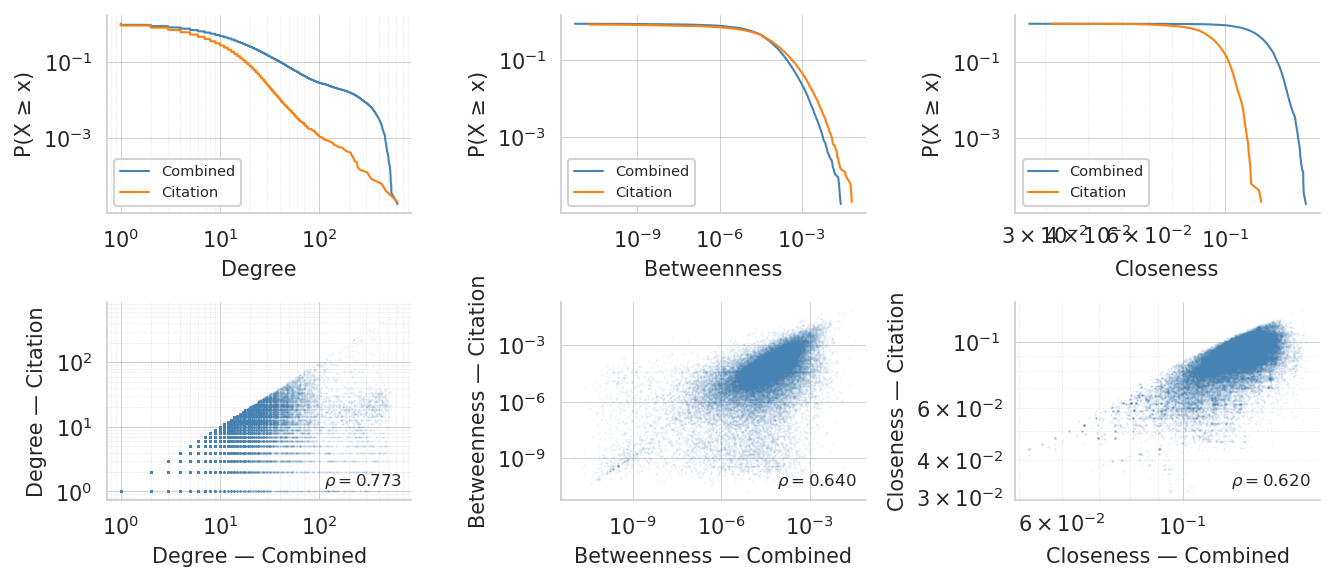

In [8]:
centralities = [
    ('Degree',      deg_c_bc, deg_c_cit),
    ('Betweenness', betw_bc,  betw_cit),
    ('Closeness',   clos_bc,  clos_cit),
]

fig, axes = plt.subplots(2, 3, figsize=(9, 4))

for j, (lbl, d_bc, d_cit) in enumerate(centralities):

    # --- riga 0: CCDF 
    ax = axes[0, j]
    for d, color, label in [(d_bc, COLORS['bc_uw'], 'Combined'),
                             (d_cit, COLORS['cit_ud'], 'Citation')]:
        x, y = ccdf(np.array(list(d.values())))
        ax.loglog(x, y, color=color, lw=1, label=label)
    ax.set_xlabel(lbl)
    ax.set_ylabel('P(X ≥ x)')
    ax.legend(fontsize=7, framealpha=0.85)
    _style_ax(ax, logx=True, logy=True)

    # --- riga 1: scatter cross-graph 
    ax   = axes[1, j]
    cn   = list(set(d_bc) & set(d_cit))
    x    = np.array([d_bc[n]  for n in cn])
    y    = np.array([d_cit[n] for n in cn])
    rho, _ = spearmanr(x, y)
    ax.scatter(x, y, color=COLORS['bc_uw'], alpha=0.1, s=1, lw=0)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(f'{lbl} — Combined')
    ax.set_ylabel(f'{lbl} — Citation')
    ax.text(0.97, 0.05, fr'$\rho={rho:.3f}$',
            transform=ax.transAxes, fontsize=8, ha='right', va='bottom')
    _style_ax(ax, logx=True, logy=True)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'centrality_analysis.png'), dpi=200, bbox_inches='tight')
plt.show()

In [9]:
from scipy.stats import poisson
from math import log, sqrt

rng = np.random.default_rng(42)

#  parametri reali 
N_b, M_b = lcc['bc_uw'].number_of_nodes(),  lcc['bc_uw'].number_of_edges()
N_c, M_c = lcc['cit_ud'].number_of_nodes(), lcc['cit_ud'].number_of_edges()
k_avg_b, k_avg_c = 2*M_b/N_b, 2*M_c/N_c
deg_seq_b = [d for _, d in lcc['bc_uw'].degree()]
deg_seq_c = [d for _, d in lcc['cit_ud'].degree()]
print(f"Combined LCC: N={N_b:,}  M={M_b:,}  ⟨k⟩={k_avg_b:.2f}")
print(f"Citation LCC: N={N_c:,}  M={M_c:,}  ⟨k⟩={k_avg_c:.2f}")

#  fit power-law (MLE, Clauset 2009) 
def fit_powerlaw_gamma(degrees, k_min=None):
    d = np.array(degrees); d = d[d > 0]
    if k_min is None:
        best_ks, best_km = np.inf, 1
        for km in range(1, min(51, int(np.percentile(d, 90)))):
            tail = d[d >= km]
            if len(tail) < 50: break
            n     = len(tail)
            gamma = 1 + n / np.sum(np.log(tail / (km - 0.5)))
            cdf_emp = np.arange(1, n+1) / n
            cdf_th  = 1 - (np.sort(tail) / (km - 0.5)) ** (-(gamma - 1))
            ks = np.max(np.abs(cdf_emp - cdf_th))
            if ks < best_ks: best_ks, best_km = ks, km
        k_min = best_km
    tail = d[d >= k_min]; n = len(tail)
    return round(1 + n / np.sum(np.log(tail / (k_min - 0.5))), 2), k_min, n

gamma_b, kmin_b, ntail_b = fit_powerlaw_gamma(deg_seq_b)
gamma_c, kmin_c, ntail_c = fit_powerlaw_gamma(deg_seq_c)
print(f"\nFitted power-law exponents:")
print(f"  Combined: γ={gamma_b}, k_min={kmin_b}, tail nodes={ntail_b:,}")
print(f"  Citation: γ={gamma_c}, k_min={kmin_c}, tail nodes={ntail_c:,}")

#  null models 
print("\nGenerating null models ...")
er_b = nx.gnm_random_graph(N_b, M_b, seed=42)
er_c = nx.gnm_random_graph(N_c, M_c, seed=42)
m_b  = max(1, round(M_b/N_b)); ba_b = nx.barabasi_albert_graph(N_b, m_b, seed=42)
m_c  = max(1, round(M_c/N_c)); ba_c = nx.barabasi_albert_graph(N_c, m_c, seed=42)
print(f"  ER: Combined={er_b.number_of_edges():,}  Citation={er_c.number_of_edges():,}")
print(f"  BA: Combined m={m_b} → {ba_b.number_of_edges():,}  Citation m={m_c} → {ba_c.number_of_edges():,}")

#  theoretical predictions 
def theoretical_er(N, M):
    k = 2*M/N; p = k/(N-1)
    return {'C (theory)': round(p, 6),
            'd (theory)': round(log(N)/log(k), 2) if k > 1 else float('inf'),
            'k_max (theory)': round(k + 6*sqrt(k))}

def theoretical_ba(N, m):
    return {'C (theory)': round((m/4)*(log(N)**2)/N, 6),
            'd (theory)': round(log(N)/log(log(N)), 2),
            'k_max (theory)': round(m*sqrt(N)), 'γ': 3}

def theoretical_fitted(N, gamma, k_min):
    k_max = round(k_min * N**(1/(gamma-1)))
    if   gamma <= 2:           d_pred = 'const'
    elif gamma < 3:            d_pred = round(log(log(N))/log(gamma-1), 2)
    elif abs(gamma - 3) < .05: d_pred = round(log(N)/log(log(N)), 2)
    else:                      d_pred = '~ln N'
    return {'γ': gamma, 'k_min': k_min, 'k_max (γ-fit)': k_max, 'd (γ-fit)': d_pred}

th_er_b,  th_er_c  = theoretical_er(N_b, M_b),           theoretical_er(N_c, M_c)
th_ba_b,  th_ba_c  = theoretical_ba(N_b, m_b),           theoretical_ba(N_c, m_c)
th_fit_b, th_fit_c = theoretical_fitted(N_b, gamma_b, kmin_b), theoretical_fitted(N_c, gamma_c, kmin_c)

print("\nTheoretical predictions:")
for gname, th_er, th_ba, th_fit in [("Combined", th_er_b, th_ba_b, th_fit_b),
                                      ("Citation",  th_er_c, th_ba_c, th_fit_c)]:
    print(f"\n  {gname}:")
    print(f"    ER:  C={th_er['C (theory)']:.6f}  d={th_er['d (theory)']:.2f}  k_max≈{th_er['k_max (theory)']}")
    print(f"    BA:  C={th_ba['C (theory)']:.6f}  d={th_ba['d (theory)']:.2f}  k_max≈{th_ba['k_max (theory)']}  (γ=3)")
    print(f"    Fit: γ={th_fit['γ']}  k_max≈{th_fit['k_max (γ-fit)']}  d≈{th_fit['d (γ-fit)']}")

#  empirical stats sui null models 
def nm_stats(G, label, n_samp=500):
    L    = G.subgraph(max(nx.connected_components(G), key=len)).copy() if not nx.is_connected(G) else G
    cl   = nx.average_clustering(L)
    samp = rng.choice(list(L.nodes()), size=min(n_samp, L.number_of_nodes()), replace=False)
    ds   = [d for n in samp for d in nx.single_source_shortest_path_length(L, n).values() if d > 0]
    degs = np.array([d for _, d in G.degree()])
    return {'Graph': label, 'N': G.number_of_nodes(), 'M': G.number_of_edges(),
            'LCC': L.number_of_nodes(),
            '⟨k⟩': round(2*L.number_of_edges()/L.number_of_nodes(), 2),
            'C (emp)': round(cl, 6), 'd (emp)': round(float(np.mean(ds)), 2),
            'Diam (est)': int(np.max(ds)), 'k_max (emp)': int(degs.max()),
            'σ_k (emp)': round(float(degs.std()), 2)}

def real_row(G, label, sp_dict, clust_avg):
    degs = np.array([d for _, d in G.degree()])
    return {'Graph': label, 'N': G.number_of_nodes(), 'M': G.number_of_edges(),
            'LCC': G.number_of_nodes(),
            '⟨k⟩': round(2*G.number_of_edges()/G.number_of_nodes(), 2),
            'C (emp)': round(clust_avg, 6), 'd (emp)': round(sp_dict['avg_path'], 2),
            'Diam (est)': int(sp_dict['diameter']), 'k_max (emp)': int(degs.max()),
            'σ_k (emp)': round(float(degs.std()), 2)}

print("\nComputing empirical null-model metrics (500-node BFS sample) ...")
t0 = time.time()
s_er_b = nm_stats(er_b, 'ER'); s_er_c = nm_stats(er_c, 'ER')
s_ba_b = nm_stats(ba_b, 'BA'); s_ba_c = nm_stats(ba_c, 'BA')
print(f"  Done in {time.time()-t0:.1f}s")

r_real_b = real_row(lcc['bc_uw'],  'Real', sp_bc,  clust_bc_m)
r_real_c = real_row(lcc['cit_ud'], 'Real', sp_cit, clust_cit_m)

#  tabelle di confronto 
def build_table(r_real, s_er, s_ba, th_er, th_ba, th_fit):
    extras = lambda th, g: {'C (theory)': th['C (theory)'],
                             'd (theory)': th['d (theory)'],
                             'k_max (theory)': th['k_max (theory)'], 'γ': g}
    return [
        {**r_real, 'C (theory)': '—', 'd (theory)': th_fit['d (γ-fit)'],
         'k_max (theory)': th_fit['k_max (γ-fit)'], 'γ': th_fit['γ']},
        {**s_er, **extras(th_er, '—')},
        {**s_ba, **extras(th_ba, 3)},
    ]

tab_b = build_table(r_real_b, s_er_b, s_ba_b, th_er_b, th_ba_b, th_fit_b)
tab_c = build_table(r_real_c, s_er_c, s_ba_c, th_er_c, th_ba_c, th_fit_c)

for tab in [tab_b, tab_c]:
    Ce, Le = tab[1]['C (emp)'], tab[1]['d (emp)']
    Cr, Lr = tab[0]['C (emp)'], tab[0]['d (emp)']
    sigma  = round((Cr/Ce) / (Lr/Le), 2) if Ce > 0 and Le > 0 else '—'
    for i, row in enumerate(tab):
        row['σ'] = sigma if i == 0 else '—'

cols_display = ['Graph', 'N', 'M', 'LCC', '⟨k⟩', 'γ',
                'C (emp)', 'C (theory)', 'd (emp)', 'd (theory)',
                'k_max (emp)', 'k_max (theory)', 'σ_k (emp)', 'σ']
for title, tab in [("Combined LCC vs null models", tab_b),
                   ("Citation LCC vs null models",  tab_c)]:
    print(f"\n{'═'*90}\n{title}\n{'═'*90}")
    df = pd.DataFrame(tab)
    print(df[[c for c in cols_display if c in df.columns]].set_index('Graph').to_string())

Combined LCC: N=56,045  M=586,866  ⟨k⟩=20.94
Citation LCC: N=49,243  M=209,599  ⟨k⟩=8.51

Fitted power-law exponents:
  Combined: γ=2.39, k_min=25, tail nodes=11,121
  Citation: γ=3.54, k_min=17, tail nodes=6,045

Generating null models ...
  ER: Combined=586,866  Citation=209,599
  BA: Combined m=10 → 560,350  Citation m=4 → 196,956

Theoretical predictions:

  Combined:
    ER:  C=0.000374  d=3.59  k_max≈48
    BA:  C=0.005333  d=4.57  k_max≈2367  (γ=3)
    Fit: γ=2.39  k_max≈65186  d≈7.26

  Citation:
    ER:  C=0.000173  d=5.05  k_max≈26
    BA:  C=0.002371  d=4.54  k_max≈888  (γ=3)
    Fit: γ=3.54  k_max≈1196  d≈~ln N

Computing empirical null-model metrics (500-node BFS sample) ...
  Done in 86.2s

══════════════════════════════════════════════════════════════════════════════════════════
Combined LCC vs null models
══════════════════════════════════════════════════════════════════════════════════════════
           N       M    LCC    ⟨k⟩     γ   C (emp) C (theory)  d (emp)  d (t

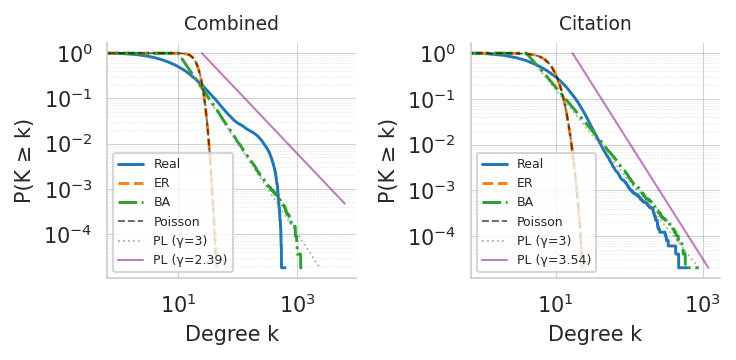

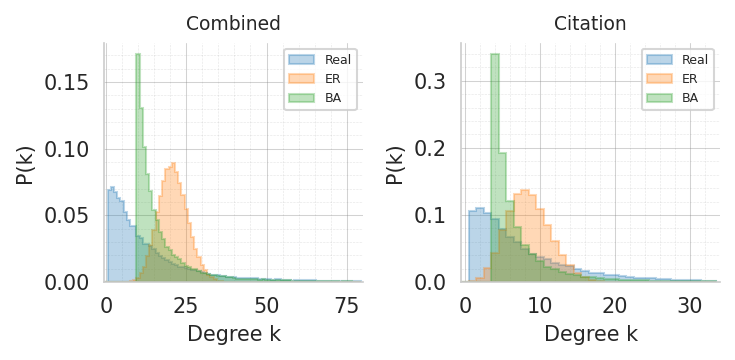

In [10]:
#  Fig 1: CCDF degree vs null models 
def degree_ccdf(G):
    degs = np.array([d for _, d in G.degree()])
    vals = np.arange(0, degs.max() + 1)
    c    = np.array([np.mean(degs >= k) for k in vals]); mask = c > 0
    return vals[mask], c[mask]

def poisson_ccdf(k_avg, k_max):
    k = np.arange(0, k_max + 1); c = 1 - poisson.cdf(k - 1, k_avg)
    return k[c > 1e-8], c[c > 1e-8]

def powerlaw_ccdf(gamma, k_min, k_max):
    k = np.arange(max(k_min, 1), k_max + 1, dtype=float)
    return k, (k / k_min) ** (-(gamma - 1))

fig, axes = plt.subplots(1, 2, figsize=(5, 2.5))
datasets = [
    (lcc['bc_uw'],  er_b, ba_b, k_avg_b, m_b, gamma_b, kmin_b, 'Combined'),
    (lcc['cit_ud'], er_c, ba_c, k_avg_c, m_c, gamma_c, kmin_c, 'Citation'),
]
for ax, (real, er, ba, kavg, m, gam, km, gname) in zip(axes, datasets):
    for G, c, lab, ls in [(real, 'tab:blue',   'Real', '-'),
                           (er,   'tab:orange', 'ER',   '--'),
                           (ba,   'tab:green',  'BA',   '-.')]:
        x, y = degree_ccdf(G); ax.loglog(x, y, color=c, label=lab, lw=1.4, ls=ls)

    # soglia: non scendere sotto il minimo della CCDF reale
    x_real, y_real = degree_ccdf(real)
    y_floor = y_real.min()

    kp, yp = poisson_ccdf(kavg, int(x_real.max()))
    mask = yp >= y_floor
    ax.loglog(kp[mask], yp[mask], color='black', ls='--', lw=0.9, alpha=0.6, label='Poisson')

    kpl, ypl = powerlaw_ccdf(3.0, m, int(m*sqrt(real.number_of_nodes())))
    mask = ypl >= y_floor
    ax.loglog(kpl[mask], ypl[mask], color='gray', ls=':', lw=0.9, alpha=0.6, label='PL (γ=3)')

    k_upper_fit = min(int(km * real.number_of_nodes()**(1/(gam-1))),
                      10*int(x_real.max()))
    kpf, ypf = powerlaw_ccdf(gam, km, k_upper_fit)
    mask = ypf >= y_floor
    ax.loglog(kpf[mask], ypf[mask], color='purple', ls='-', lw=1, alpha=0.5,
              label=f'PL (γ={gam})')

    ax.set_xlabel('Degree k'); ax.set_ylabel('P(K ≥ k)')
    ax.legend(fontsize=6, loc='lower left'); ax.set_title(gname, fontsize=9)
    _style_ax(ax, logx=True, logy=True)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'degree_ccdf_vs_null.png'), dpi=200, bbox_inches='tight')
plt.show()

#  Fig 2: PDF lineare, regime basso-k 
fig, axes = plt.subplots(1, 2, figsize=(5, 2.5))
for ax, (real, er, ba, kavg, gname) in zip(axes, [
    (lcc['bc_uw'],  er_b, ba_b, k_avg_b, 'Combined'),
    (lcc['cit_ud'], er_c, ba_c, k_avg_c, 'Citation'),
]):
    k_cut = int(min(4*kavg, 80))
    for G, c, lab in [(real, 'tab:blue', 'Real'), (er, 'tab:orange', 'ER'), (ba, 'tab:green', 'BA')]:
        degs = np.array([d for _, d in G.degree()])
        ax.hist(degs, bins=np.arange(0, k_cut+1)-0.5, density=True,
                alpha=0.3, color=c, label=lab, edgecolor=c, lw=0.7, histtype='stepfilled')
    k_th = np.arange(0, k_cut+1)
    ax.set_xlabel('Degree k'); ax.set_ylabel('P(k)')
    ax.set_xlim(-0.5, k_cut); ax.legend(fontsize=6); ax.set_title(gname, fontsize=9)
    _style_ax(ax)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'degree_pdf_linear.png'), dpi=200, bbox_inches='tight')
plt.show()

Clustering weighted vs unweighted: ρ=1.0000  (n=56,045)
Degree assortativity:
  Combined (weighted)          r = 0.8141
  Combined (unweighted)        r = 0.8141
  Citation (undirected)        r = 0.0552
  Citation (directed)          r = 0.1208
K-core max — Combined: 188  |  Citation: 21


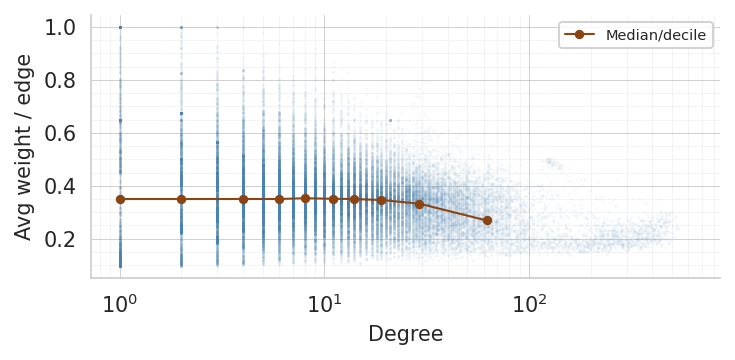

Computing directed metrics ...
  Reciprocity: 0.006892  (1,502 / 217,925 = 0.69%)

Directed metrics

        In-degree  Out-degree  PageRank
Mean     3.956661    3.956661  0.000018
Std      8.581076    4.817520  0.000032
Median   2.000000    2.000000  0.000010
Max    616.000000  128.000000  0.002243
P90     10.000000   10.000000  0.000034
P99     28.000000   22.000000  0.000138
  Spearman PR vs In: ρ=0.9036  p=<0.001
  Spearman In vs Out: ρ=0.0900  p=<0.001


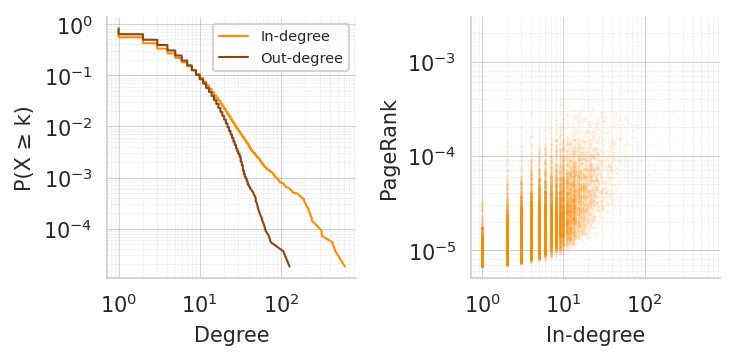

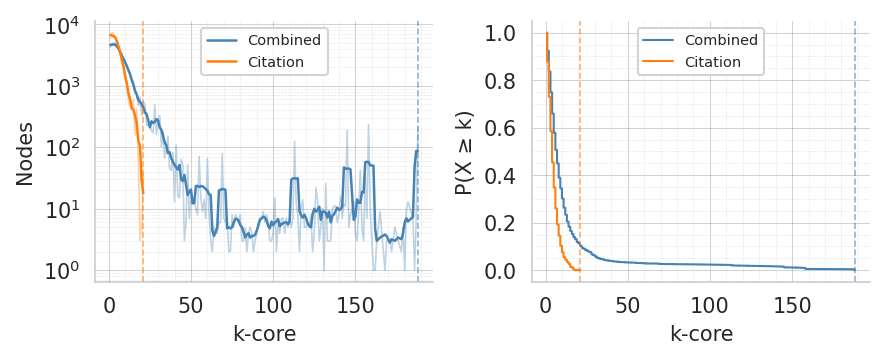

Cross-metric summary by node role (Combined LCC):

  Role                      N  Deg(mean)  Betw(mean)  Clos(mean)  Str(mean)
--------------------------------------------------------------------------
  Global Hub              330   118.8545      0.0019      0.1510    118.8545
  Local Hub               790   190.4367      0.0000      0.1377    190.4367
  Strategic Bridge        369     6.4688      0.0012      0.1232      6.4688
  Intermediate         14,692    22.8599      0.0001      0.1301     22.8599
  Uncategorized        39,864    16.2006      0.0001      0.1192     16.2006


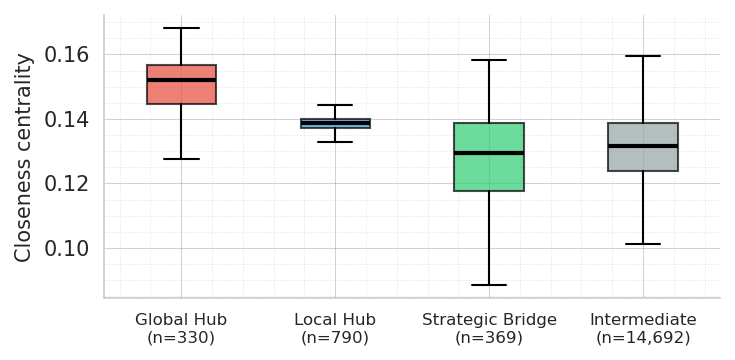

In [11]:
def _style_ax(ax, logx=False, logy=False):
    ax.grid(True, which='major', ls='-',  lw=0.5, alpha=0.35, color='gray')
    ax.grid(True, which='minor', ls='--', lw=0.3, alpha=0.20, color='gray')
    ax.minorticks_on()
    fmt = ticker.LogFormatterSciNotation(labelOnlyBase=False)
    if logx: ax.xaxis.set_major_formatter(fmt)
    if logy: ax.yaxis.set_major_formatter(fmt)
    for sp in ['top', 'right']: ax.spines[sp].set_visible(False)


#  preparazione dati 
node_deg = dict(G_combined_w.degree())
node_str = dict(G_combined_w.degree(weight='weight'))
strength = dict(lcc['bc_uw'].degree(weight='weight'))

common_w = [n for n in node_deg if node_deg[n] > 0]
xd       = np.array([node_deg[n]               for n in common_w])
yw       = np.array([node_str[n] / node_deg[n]  for n in common_w])

order      = np.argsort(xd)
xd_s, yw_s = xd[order], yw[order]
bins       = np.array_split(np.arange(len(xd_s)), 10)
bx         = np.array([np.median(xd_s[b]) for b in bins])
bm         = np.array([np.median(yw_s[b]) for b in bins])

clust_uw_full = nx.clustering(lcc['bc_uw'])
clust_w_vals  = nx.clustering(lcc['bc_uw'], weight='weight')
c_common      = list(set(clust_uw_full) & set(clust_w_vals))
rho_c, _      = spearmanr([clust_uw_full[n] for n in c_common],
                           [clust_w_vals[n]  for n in c_common])
print(f"Clustering weighted vs unweighted: ρ={rho_c:.4f}  (n={len(c_common):,})")

assort = {k: nx.degree_assortativity_coefficient(G) for k, G in graphs.items()}
print("Degree assortativity:")
for k, v in assort.items():
    print(f"  {NAMES[k]:<28} r = {v:.4f}")

kcore_bc  = nx.core_number(lcc['bc_uw'])
kcore_cit = nx.core_number(lcc['cit_ud'])
kv_bc     = np.array(list(kcore_bc.values()))
kv_cit    = np.array(list(kcore_cit.values()))
km_bc, km_cit = int(kv_bc.max()), int(kv_cit.max())
print(f"K-core max — Combined: {km_bc}  |  Citation: {km_cit}")


#  Fig 1: hub dilution 
fig, ax = plt.subplots(figsize=(5, 2.5))
ax.scatter(xd, yw, alpha=0.04, s=2, color=COLORS['bc_uw'], lw=0)
ax.plot(bx, bm, marker='o', ms=3.5, color='saddlebrown', lw=1, label='Median/decile')
ax.set_xscale('log')
ax.set_xlabel('Degree'); ax.set_ylabel('Avg weight / edge')
ax.legend(fontsize=7, framealpha=0.85)
_style_ax(ax, logx=True)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'hub_dilution.png'), dpi=200, bbox_inches='tight')
plt.show()


#  directed metrics 
print("Computing directed metrics ...")
in_deg   = dict(G_cit_d.in_degree())
out_deg  = dict(G_cit_d.out_degree())
pagerank = nx.pagerank(G_cit_d, alpha=0.85, max_iter=200, tol=1e-6)
recip    = nx.reciprocity(G_cit_d)
n_recip  = sum(1 for u, v in G_cit_d.edges() if G_cit_d.has_edge(v, u))
print(f"  Reciprocity: {recip:.6f}  ({n_recip:,} / {G_cit_d.number_of_edges():,} = "
      f"{n_recip/G_cit_d.number_of_edges()*100:.2f}%)")

iv, ov, pv = (np.array(list(d.values())) for d in (in_deg, out_deg, pagerank))

df_dir = pd.DataFrame(
    {l: [round(f(a), 6) for _, f in fns]
     for l, a in [('In-degree', iv), ('Out-degree', ov), ('PageRank', pv)]},
    index=[n for n, _ in fns])
print("\nDirected metrics\n"); print(df_dir.to_string(float_format=lambda x: f'{x:.6f}'))

cd = list(set(in_deg) & set(out_deg) & set(pagerank))
for label, x, y in [('PR vs In', pagerank, in_deg), ('In vs Out', in_deg, out_deg)]:
    r, p = spearmanr([x[n] for n in cd], [y[n] for n in cd])
    print(f"  Spearman {label}: ρ={r:.4f}  p={'<0.001' if p < .001 else f'{p:.3f}'}")

mx_pr, mx_in = max(pv), max(iv)
delta = {n: pagerank[n]/mx_pr - in_deg[n]/mx_in for n in cd}


#  Fig 2: directed analysis (2 pannelli) 
fig, axes = plt.subplots(1, 2, figsize=(5, 2.5))

ax = axes[0]
for a, color, label in [(iv, COLORS['cit_d'], 'In-degree'), (ov, 'saddlebrown', 'Out-degree')]:
    s = np.sort(a[a > 0])[::-1]
    ax.loglog(s, np.arange(1, len(s)+1)/len(a), color=color, lw=1, label=label)
ax.set_xlabel('Degree'); ax.set_ylabel('P(X ≥ k)')
ax.legend(fontsize=7, framealpha=0.85)
_style_ax(ax, logx=True, logy=True)

ax = axes[1]
ax.scatter(list(in_deg.values()), list(pagerank.values()),
           alpha=0.05, s=2, color=COLORS['cit_d'], lw=0)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('In-degree'); ax.set_ylabel('PageRank')
_style_ax(ax, logx=True, logy=True)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'directed_analysis.png'), dpi=200, bbox_inches='tight')
plt.show()


#  Fig 3: k-core (2 pannelli) 
fig, axes = plt.subplots(1, 2, figsize=(6, 2.5))

ax = axes[0]
for kv, color, label in [(kv_bc, COLORS['bc_uw'], 'Combined'), (kv_cit, COLORS['cit_ud'], 'Citation')]:
    cnt = Counter(kv); ks = np.array(sorted(cnt)); ns = np.array([cnt[k] for k in ks], dtype=float)
    ax.semilogy(ks, ns, color=color, lw=0.8, alpha=0.35)
    smoothed = uniform_filter1d(ns, 5) if len(ns) > 10 else ns
    ax.semilogy(ks, smoothed, color=color, lw=1.2, label=label,
                **({} if len(ns) > 10 else {'marker': 's', 'ms': 3}))
for val, color in [(km_bc, COLORS['bc_uw']), (km_cit, COLORS['cit_ud'])]:
    ax.axvline(val, color=color, lw=0.8, ls='--', alpha=0.6)
ax.set_xlabel('k-core'); ax.set_ylabel('Nodes')
ax.legend(fontsize=7, framealpha=0.85)
_style_ax(ax, logy=True)

ax = axes[1]
for kv, color, label in [(kv_bc, COLORS['bc_uw'], 'Combined'), (kv_cit, COLORS['cit_ud'], 'Citation')]:
    s = np.sort(kv)[::-1]
    ax.plot(s, np.arange(1, len(s)+1)/len(s), color=color, lw=1, label=label)
for val, color in [(km_bc, COLORS['bc_uw']), (km_cit, COLORS['cit_ud'])]:
    ax.axvline(val, color=color, lw=0.8, ls='--', alpha=0.6)
ax.set_xlabel('k-core'); ax.set_ylabel('P(X ≥ k)')
ax.legend(fontsize=7, framealpha=0.85)
_style_ax(ax)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'kcore.png'), dpi=200, bbox_inches='tight')
plt.show()


#  cross-metric summary by node role 
print("Cross-metric summary by node role (Combined LCC):\n")
print(f"  {'Role':<20} {'N':>6} {'Deg(mean)':>10} {'Betw(mean)':>11} {'Clos(mean)':>11} {'Str(mean)':>10}")
print("-" * 74)
for role in ['Global Hub', 'Local Hub', 'Strategic Bridge', 'Intermediate', 'Uncategorized']:
    ns = [n for n, r in roles.items() if r == role]
    if not ns: continue
    arrs = [np.array([d.get(n, 0) for n in ns])
            for d in (deg_c_bc, betw_bc, clos_bc, strength)]
    print(f"  {role:<20} {len(ns):>6,} " + "  ".join(f"{a.mean():>10.4f}" for a in arrs))


#  Fig 4: closeness by role 
role_order  = ['Global Hub', 'Local Hub', 'Strategic Bridge', 'Intermediate']
role_colors = ['#e74c3c', '#3498db', '#2ecc71', '#95a5a6']

role_data, role_labels = [], []
for role, color in zip(role_order, role_colors):
    ns = [n for n, r in roles.items() if r == role and n in clos_bc]
    if ns:
        role_data.append([clos_bc[n] for n in ns])
        role_labels.append(f"{role}\n(n={len(ns):,})")

fig, ax = plt.subplots(figsize=(5, 2.5))
bp = ax.boxplot(role_data, tick_labels=role_labels, patch_artist=True,
                showfliers=False, medianprops=dict(color='black', lw=2))
for patch, c in zip(bp['boxes'], role_colors):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax.set_ylabel('Closeness centrality')
ax.tick_params(axis='x', labelsize=8)
_style_ax(ax)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'closeness_by_role.png'), dpi=200, bbox_inches='tight')
plt.show()